## Actividad 3_10
<div style="border-style:groove;border-width:thin;padding:10px">
Debes usar Random Forests para solucionar el ejercicio de MNIST. Recuerda que con Decision Tree llegamos al 87% de accuracy y con SVC llegamos al 98%. 
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
A continuación vamos a importar el dataset y a generar los conjuntos X e y.
    </div>

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_moons, make_circles
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz, DecisionTreeRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier


In [59]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

<div style="border-style:groove;border-width:thin;padding:10px">
1. Divide el dataset en el conjunto de entrenamiento y de test.
    </div>

In [60]:
X, y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train.shape
X_test.shape

(14000, 784)

<div style="border-style:groove;border-width:thin;padding:10px">
2. Crea un Random Forest con los parámetros que consideres oportuno para solucionar el problema.
    </div>

In [62]:
rf_clf = RandomForestClassifier(n_estimators=1000, min_samples_split=5, bootstrap=False, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=False, min_samples_split=5, n_estimators=1000,
                       random_state=42)

<div style="border-style:groove;border-width:thin;padding:10px">
3. Genera la predicción (y_pred) con el árbol entrenado y mira la precisión que has conseguido. Módifica los parámetros del árbol en el código del punto 2 para mejorar los resultados.
    </div>

In [63]:
y_pred = rf_clf.predict(X_test)

In [64]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del árbol de decisión: {accuracy:.4f} ({accuracy*100:.2f}%)")

Precisión del árbol de decisión: 0.9710 (97.10%)


<div style="border-style:groove;border-width:thin;padding:10px">
4. Recorre la muestra de test viendo los datos que son erróneos y muestra la imagen. Evalúa si el resultado es suficientemente bueno.
</div>

Número total de errores: 406 de 14000


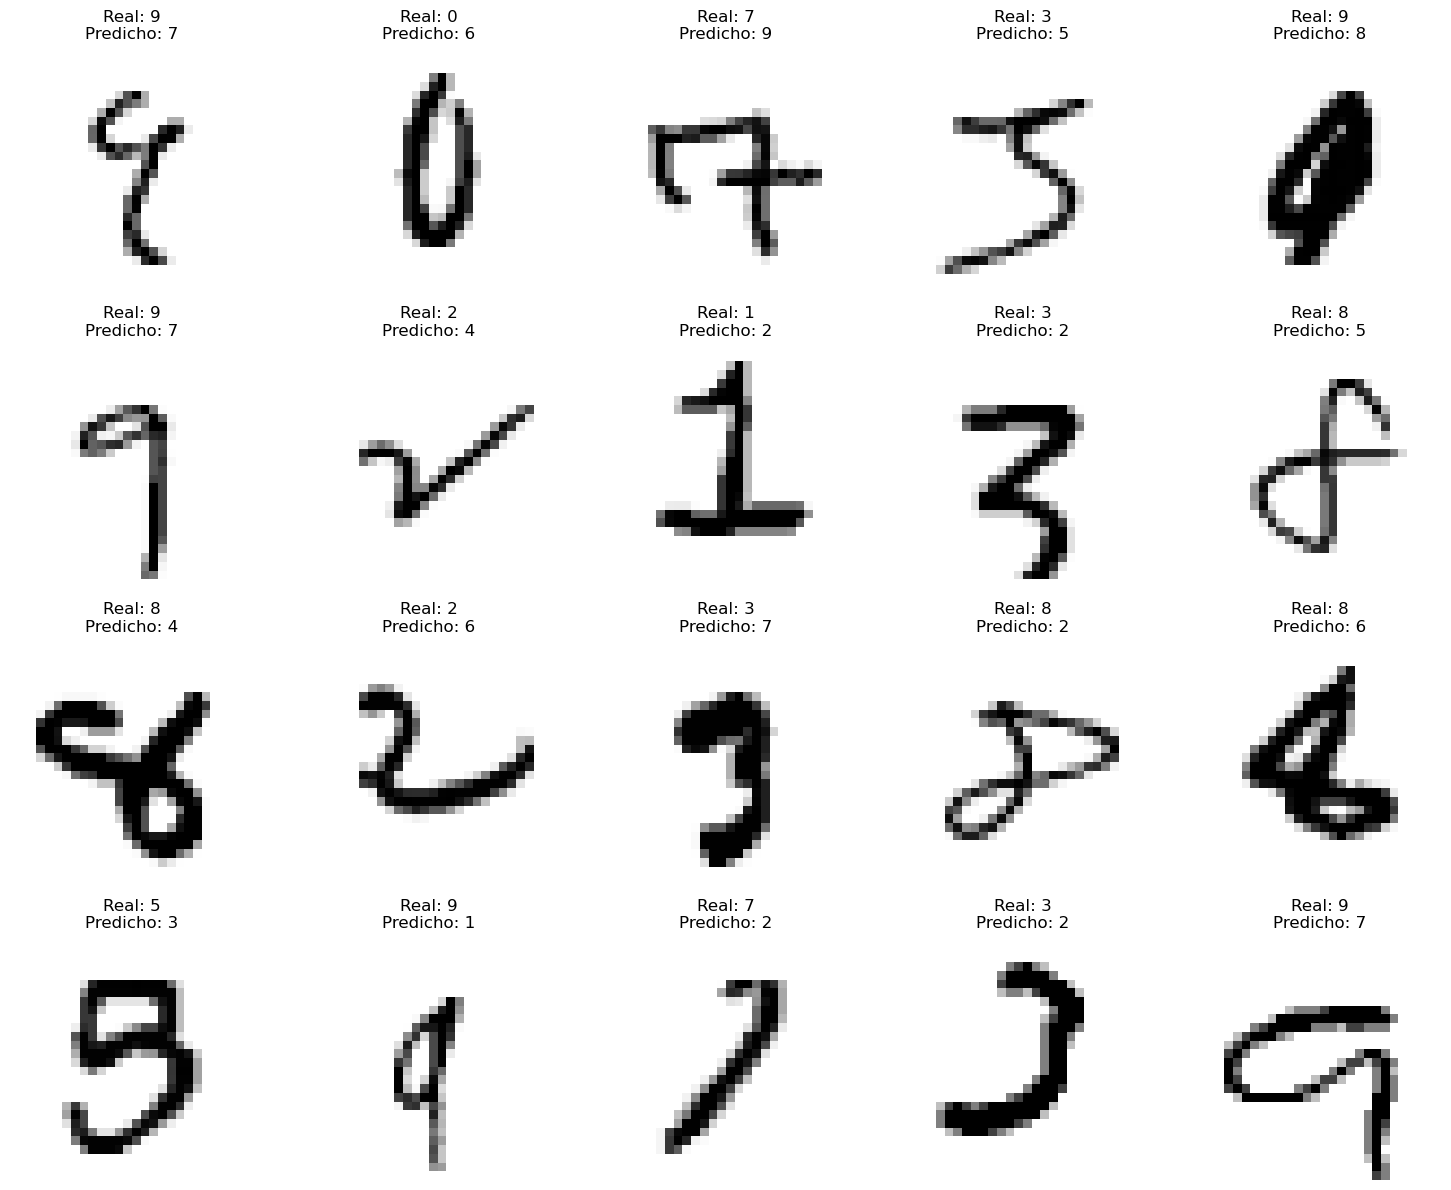

In [65]:
import numpy as np

y_test_array = y_test.values if hasattr(y_test, 'values') else y_test
errores = y_test_array != y_pred
indices_errores = np.where(errores)[0]

print(f"Número total de errores: {len(indices_errores)} de {len(y_test)}")

# Mostrar algunos ejemplos de errores
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.ravel()

for i in range(min(20, len(indices_errores))):
    idx = indices_errores[i]
    imagen = X_test.iloc[idx].values.reshape(28, 28)
    
    axes[i].imshow(imagen, cmap='binary')
    axes[i].axis('off')
    axes[i].set_title(f'Real: {y_test_array[idx]}\nPredicho: {y_pred[idx]}')

plt.tight_layout()
plt.show()

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.ensemble import RandomForestClassifier

# param_dist = {
#     'n_estimators': [100, 200, 300, 500],
#     'max_features': ['sqrt', 'log2'],
#     'max_depth': [None, 20, 30],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2],
#     'bootstrap': [True, False],
# }

# rf = RandomForestClassifier(n_jobs=-1, random_state=42)

# search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_dist,
#     n_iter=20,          # prueba 20 combinaciones aleatorias
#     cv=3,               # validación cruzada 3 folds
#     scoring='accuracy',
#     n_jobs=-1,
#     random_state=42,
#     verbose=2
# )

# search.fit(X_train, y_train)

# print("Mejores parámetros:", search.best_params_)
# print("Mejor accuracy (CV):", search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  29.3s
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  32.0s
[CV] END bootstrap=False, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  32.2s
[CV] END bootstrap=False, max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  37.6s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=  38.0s
[CV] END bootstrap=False, max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  38.0s
[CV] END bootstrap=False, max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; to